# Skin Cancer Classification for Detecting Melanoma

## 1. Preprocessing

### 1.1. Data preprocessing

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import tensorflow as tf
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config=config)
tf.compat.v1.keras.backend.set_session(sess)

KeyboardInterrupt: 

In [ ]:
print(tf. __version__)

2.12.0-rc1


In [ ]:
from platform import python_version

print(python_version())

3.11.1


In [ ]:
# Importing the libraries
import numpy as np
import pandas as pd
import os
from sklearn.datasets import load_files
from keras.utils import np_utils 

In [ ]:
# Load text files with categories as subfolder names.
path = "./Dataset/"
data = load_files(path)

In [ ]:
print("Filename: \n", data['filenames'][:405])
print("Targets: \n", data['target'][:405])

Filename: 
 ['./Dataset/melanoma\\ISIC_0024987_flipped.jpg'
 './Dataset/melanoma\\ISIC_0025531_270_angle.jpg'
 './Dataset/others\\ISIC_0031236.jpg' './Dataset/others\\ISIC_0032115.jpg'
 './Dataset/others\\ISIC_0027932.jpg' './Dataset/others\\ISIC_0024863.jpg'
 './Dataset/melanoma\\ISIC_0024516_90_angle.jpg'
 './Dataset/others\\ISIC_0027646.jpg' './Dataset/others\\ISIC_0029998.jpg'
 './Dataset/others\\ISIC_0032991.jpg' './Dataset/others\\ISIC_0026613.jpg'
 './Dataset/melanoma\\ISIC_0025832_90_angle.jpg'
 './Dataset/others\\ISIC_0025771.jpg'
 './Dataset/melanoma\\ISIC_0025500_180_angle.jpg'
 './Dataset/melanoma\\ISIC_0024481_270_angle_flipped.jpg'
 './Dataset/others\\ISIC_0024687.jpg'
 './Dataset/melanoma\\ISIC_0025097_180_angle.jpg'
 './Dataset/melanoma\\ISIC_0025081_flipped.jpg'
 './Dataset/others\\ISIC_0033256.jpg'
 './Dataset/melanoma\\ISIC_0025709_90_angle_flipped.jpg'
 './Dataset/others\\ISIC_0026054.jpg'
 './Dataset/melanoma\\ISIC_0024999_90_angle.jpg'
 './Dataset/melanoma\\ISIC_0

In [ ]:
# Getting the labels
target = np_utils.to_categorical(np.array(data['target']), 2)
target

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

In [ ]:
len(data['filenames'])

3216

In [ ]:
# Splitting the data into the training and validation set
train_files, train_targets = data['filenames'][:1000], target[:1000]
valid_files, valid_targets = data['filenames'][1000:1300], target[1000:1300]

### 1.2. Image preprocessing

In [ ]:
# Importing the libraries
import keras
import keras.utils as image             
from tqdm import tqdm
from PIL import ImageFile                            
ImageFile.LOAD_TRUNCATED_IMAGES = True                 

In [ ]:
def path_to_tensor(img_path):
    """
    Getting a tensor from a given path.
    """
    # Loading the image
    img = image.load_img(img_path, target_size=(512, 512))
    # Converting the image to numpy array
    x = image.img_to_array(img)   
    # convert 3D tensor to 4D tensor with shape (1, 512, 512, 3)
    return np.expand_dims(x, axis=0)

def paths_to_tensor(img_paths):
    """
    # Getting a list of tensors from a given path directory.
    """
    list_of_tensors = [path_to_tensor(img_path) for img_path in tqdm(img_paths)]
    return np.vstack(list_of_tensors)

In [ ]:
# pre-process the data for Keras
train_tensors = paths_to_tensor(train_files).astype('float32')/255
valid_tensors = paths_to_tensor(valid_files).astype('float32')/255

100%|██████████| 916/916 [00:06<00:00, 144.79it/s]


In [ ]:
# Saving the data
np.save("./Saved image tensors/augmented_training_tensors.npy", train_tensors)
np.save("./Saved image tensors/augmented_validation_tensors.npy", valid_tensors)

In [85]:
# Loading the data
train_tensors = np.load("./Saved image tensors/augmented_training_tensors.npy")
valid_tensors = np.load("./Saved image tensors/augmented_validation_tensors.npy")

## 2. Training the model

In [20]:
# Importing the keras libraries
import keras
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Flatten, BatchNormalization, Activation, Dropout
from keras.callbacks import ModelCheckpoint, TensorBoard
# from tensorflow.keras.applications.mobilenet import MobileNet
# from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import ModelCheckpoint

### 2.1. MobileNet architecture

In [45]:
def mobilenet_architecture():
    """
    Pre-build architecture of mobilenet for our dataset.
    """
    # Imprting the model
    from keras.applications.mobilenet import MobileNet

    # Pre-build model
    base_model = MobileNet(include_top = False, weights = None, input_shape = (512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    mobilenet_model = Model(base_model.input, output)
    
    # Getting the summary of architecture
    #mobilenet_model.summary()
    
    # Compiling the model
    mobilenet_model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
                            loss = 'categorical_crossentropy', 
                            metrics = ['accuracy'])

    # base_model = MobileNet(include_top=False, weights=None, input_shape=(512, 512, 3))
    # x = base_model.output
    # x = GlobalAveragePooling2D()(x)
    # output = Dense(units=2, activation='softmax')(x)
    # mobilenet_model = Model(base_model.input, output)
    # mobilenet_model.compile(optimizer=Adam(lr=0.001),
    #                         loss='categorical_crossentropy',
    #                         metrics=['accuracy'])
    return mobilenet_model

In [46]:
# Getting the mobilenet
mobilenet_model = mobilenet_architecture()

In [47]:
# import pyswarms as ps
# import numpy as np
# from keras.callbacks import ModelCheckpoint
# def optimize_hyperparameters(model, X_train, y_train):
#     """
#     Optimize hyperparameters of the given model using PSO.
#     """
#     def objective_function(params):
#         """
#         Objective function to be minimized by PSO.
#         """
#         # Set the hyperparameters to the given values
#         print(params)
#         model.optimizer.lr = params
#         # model.optimizer.decay = params[1]
#         # model.optimizer.momentum = params[2]
#         checkpointer1 = ModelCheckpoint(filepath='Saved models bio/weights.best.mobilenet.hdf5', 
#                                verbose=1, 
#                                save_best_only=True)
        
#         # Train the model
#         history = model.fit(X_train, y_train, epochs=10, batch_size=8, validation_split=0.2, verbose=0, callbacks=[checkpointer1])
        
#         # Get the validation accuracy
#         val_acc = history.history['val_accuracy'][-1]
        
#         return -val_acc # Minimize negative validation accuracy

#     options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
#     bounds = ((0.0001,), (0.01,))  # Define bounds for each particle  # Define bounds for each particle
#     # init_pos = np.random.uniform(0, 1, (1, 3, 3))[0]  # Define initial positions for particles
#     # Initialize the PSO optimizer
#     optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=1, bounds=bounds, options=options )
#     # Optimize the objective function using PSO
#     best_params, best_value = optimizer.optimize(objective_function, iters=50)

#     return best_params


In [48]:
# n_particles=10
# dimensions=1
# bounds = ((0.0001,), (0.01,))  # Define bounds for each particle
# lb, ub = bounds
# lb
# min_bounds = np.repeat(
#                 np.array(lb)[np.newaxis, :], n_particles, axis=0
#             )
# max_bounds = np.repeat(
#                 np.array(ub)[np.newaxis, :], n_particles, axis=0
#             )
# pos = 1.0 * np.random.uniform(
#                 low=min_bounds, high=max_bounds, size=(n_particles, dimensions)
#             )

In [49]:
# print(min_bounds.shape)
# print(max_bounds.shape)
# print(pos.shape)

In [50]:
[1,2,3]

[1, 2, 3]

In [51]:
# best_params = optimize_hyperparameters(mobilenet_model, train_tensors, train_targets)

In [86]:
model_architecture = mobilenet_architecture()
weight_path = "./Saved models bio/weights.best.mobilenet.hdf5"

In [87]:
def predict(img_path, 
            model_architecture = model_architecture, 
            path_model_weight = weight_path):
    # Getting the tensor of image
    image_to_predict = path_to_tensor(img_path).astype('float32')/255
    # Getting the model's architecture
    model = model_architecture
    # Loading the weights
    model.load_weights(path_model_weight)
    # Predicting
    pred = model.predict(image_to_predict)
    print("Prediction..." + " Melanoma : ", pred[0][0], " | Other : ", pred[0][1])
    if np.argmax(pred) == 0:
        return [1., 0.]
    elif np.argmax(pred) == 1:
        return [0., 1.]

In [88]:
# Import required libraries
import numpy as np
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pyswarm import pso

# Define the fitness function to optimize
def fitness(params):
    # Extract the learning rate and batch size parameters
    # lr, batch_size, beta_1, beta_2, epsilon = params
    lr = params[0]
    print(lr,params,
        #    batch_size, beta_1, beta_2, epsilon,
           "------------------------")
    
    # Define the model
    model = mobilenet_architecture()
    
    # Compile the model with the given learning rate
    model.optimizer = Adam(learning_rate=lr)
    
    # Train the model with the given batch size
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    checkpointer1 = ModelCheckpoint(filepath='Saved models bio/weights.best.mobilenet.hdf5', 
                               verbose=1, 
                               save_best_only=True)
    model.fit(train_tensors, train_targets,batch_size=4, epochs=5, validation_split=0.2, callbacks=[early_stopping, checkpointer1], verbose=0)
    
    # # Evaluate the model on the testing set
    # y_pred = model.predict(X_test)
    # y_pred = np.argmax(y_pred, axis=1)
    # acc = accuracy_score(np.argmax(y_test, axis=1), y_pred)

    # Compute test set predictions
    NUMBER_TEST_SAMPLES = 50

    y_true = valid_targets[:NUMBER_TEST_SAMPLES]
    y_score = []
    for index in range(NUMBER_TEST_SAMPLES): #compute one at a time due to memory constraints
        probs = predict(img_path = valid_files[index])
        y_score.append(probs)
    correct = np.array(y_true) == np.array(y_score)
    acc = (np.mean(correct)*100)
    print("Accuracy of current batch: ", acc)
    # Return the negative accuracy as the fitness value
    return -acc

# Define the lower and upper bounds of the search space for learning rate and batch size
# lb = [1e-6, 8, 0.5, 0.9, 1e-7]
# ub = [1e-2, 32, 1, 1, 1e-6]
lb = [1e-6]
ub = [1e-2]

# Run the PSO algorithm to optimize the parameters
xopt, fopt = pso(fitness, lb, ub, swarmsize=2, maxiter=1)

# Print the optimal parameters and accuracy
print('Optimal learning rate:', xopt[0])
# print('Optimal batch size:', int(xopt[1]))
print('Optimal accuracy:', -fopt)


0.0009697506007581104 [0.00096975] ------------------------

Epoch 1: val_loss improved from inf to 1.19038, saving model to Saved models bio\weights.best.mobilenet.hdf5

Epoch 2: val_loss improved from 1.19038 to 0.29046, saving model to Saved models bio\weights.best.mobilenet.hdf5

Epoch 3: val_loss improved from 0.29046 to 0.17503, saving model to Saved models bio\weights.best.mobilenet.hdf5

Epoch 4: val_loss did not improve from 0.17503

Epoch 5: val_loss did not improve from 0.17503
1/1 [==============================] - 1s 545ms/step
Prediction... Melanoma :  0.9993863  | Other :  0.0006136225
1/1 [==============================] - 0s 89ms/step
Prediction... Melanoma :  0.9988846  | Other :  0.001115367
1/1 [==============================] - 0s 88ms/step
Prediction... Melanoma :  0.13271977  | Other :  0.8672802
1/1 [==============================] - 0s 85ms/step
Prediction... Melanoma :  0.084078655  | Other :  0.9159214
1/1 [==============================] - 0s 85ms/step
Predi

KeyboardInterrupt: 

In [ ]:
from keras import backend as K
def spo_mobilenet_architecture():
    """
    Pre-build architecture of mobilenet for our dataset.
    """
    # Importing the necessary modules
    from keras.applications.mobilenet import MobileNet
    from keras.layers import GlobalAveragePooling2D, Dense
    from keras.models import Model

    # Pre-build model
    base_model = MobileNet(include_top=False, weights=None, input_shape=(512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units=2, activation='softmax')(x)

    # Creating the whole model
    mobilenet_model = Model(base_model.input, output)
    
    # Compiling the model with Sparrow optimizer
    from keras.optimizers import Optimizer

    class Sparrow(Optimizer):
        def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8, **kwargs):
            super(Sparrow, self).__init__( **kwargs)
            self.learning_rate = learning_rate
            # K.set_value(self.learning_rate, learning_rate)
            self.beta_1 = K.variable(beta_1)
            self.beta_2 = K.variable(beta_2)
            self.epsilon = epsilon
            self.iterations = K.variable(0)
            

        def get_updates(self, params, loss):
            grads = self.get_gradients(loss, params)
            self.updates = [K.update_add(self.iterations, 1)]

            t = self.iterations + 1

            lr_t = self.learning_rate * K.sqrt(1. - K.pow(self.beta_2, t)) / (1. - K.pow(self.beta_1, t))

            ms = [K.zeros(K.int_shape(p), dtype=K.dtype(p)) for p in params]
            vs = [K.zeros(K.int_shape(p), dtype=K.dtype(p)) for p in params]
            sparrow_params = [K.zeros(K.int_shape(p), dtype=K.dtype(p)) for p in params]

            self.weights = [self.iterations] + ms + vs + sparrow_params

            for p, g, m, v, sp in zip(params, grads, ms, vs, sparrow_params):
                m_t = (self.beta_1 * m) + (1. - self.beta_1) * g
                v_t = (self.beta_2 * v) + (1. - self.beta_2) * K.square(g)

                sp_t = - (lr_t / (K.sqrt(v_t) + self.epsilon)) * m_t

                self.updates.append(K.update(m, m_t))
                self.updates.append(K.update(v, v_t))
                self.updates.append(K.update(sp, sp_t))

                new_p = p + sp_t

                self.updates.append(K.update(p, new_p))

            return self.updates


    mobilenet_model.compile(optimizer=Sparrow(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8), 
                            loss='categorical_crossentropy', 
                            metrics=['accuracy'])
    
    return mobilenet_model

In [23]:
tf.compat.v1.enable_eager_execution()

In [ ]:
spo_mobilenet_architecture = spo_mobilenet_architecture()

In [60]:
# # Set the best hyperparameters
# mobilenet_model.optimizer.lr = best_params[0]
# mobilenet_model.optimizer.decay = best_params[1]
# mobilenet_model.optimizer.momentum = best_params[2]
from keras.callbacks import ModelCheckpoint
checkpointer = ModelCheckpoint(filepath='Saved models/weights.best.mobilenet.hdf5', 
                               verbose=1, 
                               save_best_only=True)

mobilenet_model.fit(train_tensors, 
                    train_targets, 
                    batch_size = 8,
                    validation_data = (valid_tensors, valid_targets),
                    epochs = 5,
                    callbacks=[checkpointer], 
                    verbose=1)

# spo_mobilenet_architecture.fit(train_tensors, 
#                     train_targets, 
#                     batch_size = 8,
#                     validation_data = (valid_tensors, valid_targets),
#                     epochs = 5,
#                     callbacks=[checkpointer], 
#                     verbose=1)

Epoch 1/5
288/288 [==============================] - ETA: 0s - loss: 0.4025 - accuracy: 0.8270
Epoch 1: val_loss improved from inf to 0.86886, saving model to Saved models\weights.best.mobilenet.hdf5
288/288 [==============================] - 579s 2s/step - loss: 0.4025 - accuracy: 0.8270 - val_loss: 0.8689 - val_accuracy: 0.5120
Epoch 2/5
288/288 [==============================] - ETA: 0s - loss: 0.2703 - accuracy: 0.8948
Epoch 2: val_loss did not improve from 0.86886
288/288 [==============================] - 552s 2s/step - loss: 0.2703 - accuracy: 0.8948 - val_loss: 1.0245 - val_accuracy: 0.5120
Epoch 3/5
288/288 [==============================] - ETA: 0s - loss: 0.2276 - accuracy: 0.9113
Epoch 3: val_loss improved from 0.86886 to 0.17711, saving model to Saved models\weights.best.mobilenet.hdf5
288/288 [==============================] - 554s 2s/step - loss: 0.2276 - accuracy: 0.9113 - val_loss: 0.1771 - val_accuracy: 0.9301
Epoch 4/5
288/288 [==============================] - ETA: 

In [92]:
# Loading the weights
mobilenet_model.load_weights("./Saved models/weights.best.mobilenet.hdf5")

### 2.2. Inception architecture

In [ ]:
def inception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model 
    from keras.applications.inception_v3 import InceptionV3

    # Pre-build model
    base_model = InceptionV3(include_top = False, weights = None, input_shape = (512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    inception_model = Model(base_model.input, output)
    
    # Summary of the model
    #inception_model.summary()
    
    # Compiling the model
    inception_model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
                            loss = 'categorical_crossentropy', 
                            metrics = ['accuracy'])
    
    return inception_model

In [ ]:
# Getting the inception
inception_model = inception_architecture()

In [ ]:
checkpointer = ModelCheckpoint(filepath='Saved models/weights.best.inception.hdf5', 
                               verbose=1, 
                               save_best_only=True)

inception_model.fit(train_tensors, 
                    train_targets, 
                    batch_size = 8,
                    validation_data = (valid_tensors, valid_targets),
                    epochs = 5,
                    callbacks=[checkpointer], 
                    verbose=1)

Epoch 1/5
325/325 [==============================] - ETA: 0s - loss: 0.5915 - accuracy: 0.7138
Epoch 1: val_loss improved from inf to 29.33782, saving model to Saved models\weights.best.inception.hdf5
325/325 [==============================] - 1573s 5s/step - loss: 0.5915 - accuracy: 0.7138 - val_loss: 29.3378 - val_accuracy: 0.5617
Epoch 2/5
325/325 [==============================] - ETA: 0s - loss: 0.4645 - accuracy: 0.7908
Epoch 2: val_loss improved from 29.33782 to 1.39734, saving model to Saved models\weights.best.inception.hdf5
325/325 [==============================] - 1483s 5s/step - loss: 0.4645 - accuracy: 0.7908 - val_loss: 1.3973 - val_accuracy: 0.7403
Epoch 3/5
325/325 [==============================] - ETA: 0s - loss: 0.3874 - accuracy: 0.8377
Epoch 3: val_loss improved from 1.39734 to 0.59630, saving model to Saved models\weights.best.inception.hdf5
325/325 [==============================] - 1473s 5s/step - loss: 0.3874 - accuracy: 0.8377 - val_loss: 0.5963 - val_accurac

In [ ]:
# Loading the weights
inception_model.load_weights("./Saved models/weights.best.inception.hdf5")

### 2.3. Xception architecture

In [ ]:
def xception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model
    from keras.applications.xception import Xception

    # Pre-build model
    base_model = Xception(include_top = False, weights = None, input_shape = (512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    xception_model = Model(base_model.input, output)

    # Summary of the model
    #xception_model.summary()
    
    # Compiling the model
    xception_model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
                           loss = 'categorical_crossentropy', 
                           metrics = ['accuracy'])

    return xception_model

In [ ]:
# Getting the xception
xception_model = xception_architecture()

In [ ]:
tensor_board = TensorBoard(log_dir='./logs', histogram_freq = 0, batch_size = 8)

checkpointer = ModelCheckpoint(filepath='Saved models/weights.best.xception.hdf5', 
                               verbose=1, 
                               save_best_only=True)

xception_model.fit(train_tensors, 
                   train_targets, 
                   batch_size = 8,
                   validation_data = (valid_tensors, valid_targets),
                   epochs = 2,
                   callbacks=[checkpointer, tensor_board], 
                   verbose=1)

Epoch 1/2
325/325 [==============================] - ETA: 0s - loss: 0.4281 - accuracy: 0.8273
Epoch 1: val_loss improved from inf to 0.88668, saving model to Saved models\weights.best.xception.hdf5
325/325 [==============================] - 2204s 7s/step - loss: 0.4281 - accuracy: 0.8273 - val_loss: 0.8867 - val_accuracy: 0.5016
Epoch 2/2
325/325 [==============================] - ETA: 0s - loss: 0.2882 - accuracy: 0.8873
Epoch 2: val_loss improved from 0.88668 to 0.35833, saving model to Saved models\weights.best.xception.hdf5
325/325 [==============================] - 2131s 7s/step - loss: 0.2882 - accuracy: 0.8873 - val_loss: 0.3583 - val_accuracy: 0.8506


In [ ]:
# Loading the weights
xception_model.load_weights("./Saved models/weights.best.xception.hdf5")

## 3. Prediction

In [61]:
weight_path = "./Saved models/weights.best.mobilenet.hdf5"
def predict(img_path, 
            model_architecture = mobilenet_model, 
            path_model_weight = weight_path):
    # Getting the tensor of image
    image_to_predict = path_to_tensor(img_path).astype('float32')/255
    # Getting the model's architecture
    model = model_architecture
    # Loading the weights
    model.load_weights(path_model_weight)
    # Predicting
    pred = model.predict(image_to_predict)
    print("Prediction..." + " Melanoma : ", pred[0][0], " | Other : ", pred[0][1])
    if np.argmax(pred) == 0:
        return [1., 0.]
    elif np.argmax(pred) == 1:
        return [0., 1.]

In [62]:
predict("ISIC_0031649_nm.jpg")

1/1 [==============================] - 1s 572ms/step
Prediction... Melanoma :  0.26098117  | Other :  0.73901886


[0.0, 1.0]

In [68]:
predict('./Dataset/melanoma/ISIC_0024310.jpg')

1/1 [==============================] - 0s 110ms/step
Prediction... Melanoma :  0.41682917  | Other :  0.58317083


[0.0, 1.0]

## 4. Evaluating the model

In [39]:
# Importing the libraries
from sklearn.metrics import roc_curve, auc
import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

In [40]:
def compute_roc(y_true, y_score):
    """ 
    Computing the "Receiving Operating Characteristic curve" and area
    """
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_true, y_score) 
    auroc = auc(false_positive_rate, true_positive_rate) 
    return false_positive_rate, true_positive_rate, auroc

In [41]:
def plot_roc(y_true, y_score):
    """ 
    Ploting the Receiving Operating Characteristic curve
    """
    false_positive_rate, true_positive_rate, auroc = compute_roc(y_true, y_score)
    plt.figure(figsize=(10,6))
    plt.grid()
    plt.plot(false_positive_rate, 
             true_positive_rate, 
             color='darkorange',
             lw=2, 
             label='ROC curve (area = {:.2f})'.format(auroc))
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver operating characteristic example', fontsize=15)
    plt.legend(loc="lower right", fontsize=14)
    plt.show()

In [42]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [43]:
plt.style.use("seaborn-white")

C:\Users\bmpra\AppData\Local\Temp\ipykernel_17904\3081854136.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-white")


### 4.1. Evaluating MobileNet

In [64]:
# Compute test set predictions
NUMBER_TEST_SAMPLES = 100

y_true = valid_targets[:NUMBER_TEST_SAMPLES]
y_score = []
for index in range(NUMBER_TEST_SAMPLES): #compute one at a time due to memory constraints
    probs = predict(img_path = valid_files[index])

    y_score.append(probs)
    
correct = np.array(y_true) == np.array(y_score)

1/1 [==============================] - 0s 81ms/step
Prediction... Melanoma :  0.9999968  | Other :  3.171948e-06
1/1 [==============================] - 0s 92ms/step
Prediction... Melanoma :  0.9999877  | Other :  1.2298245e-05
1/1 [==============================] - 0s 87ms/step
Prediction... Melanoma :  0.3092341  | Other :  0.6907659
1/1 [==============================] - 0s 106ms/step
Prediction... Melanoma :  0.36923277  | Other :  0.63076717
1/1 [==============================] - 0s 83ms/step
Prediction... Melanoma :  0.01139098  | Other :  0.9886091
1/1 [==============================] - 0s 85ms/step
Prediction... Melanoma :  1.0  | Other :  4.848282e-08
1/1 [==============================] - 0s 79ms/step
Prediction... Melanoma :  0.9990207  | Other :  0.0009793531
1/1 [==============================] - 0s 85ms/step
Prediction... Melanoma :  0.038738735  | Other :  0.9612613
1/1 [==============================] - 0s 94ms/step
Prediction... Melanoma :  0.17474884  | Other :  0.8252

In [65]:
print("Accuracy = %2.2f%%" % (np.mean(correct)*100))

Accuracy = 92.00%


In [36]:
# Re-ordering the actual y (for ROC)
y_true_2 = []
for i in range(len(y_true)):
    y_true_2.append(y_true[i][0])

In [37]:
# Re-ordering the predicte y (for ROC)
y_score_2 = []
for i in range(len(y_score)):
    y_score_2.append(y_score[i][0])

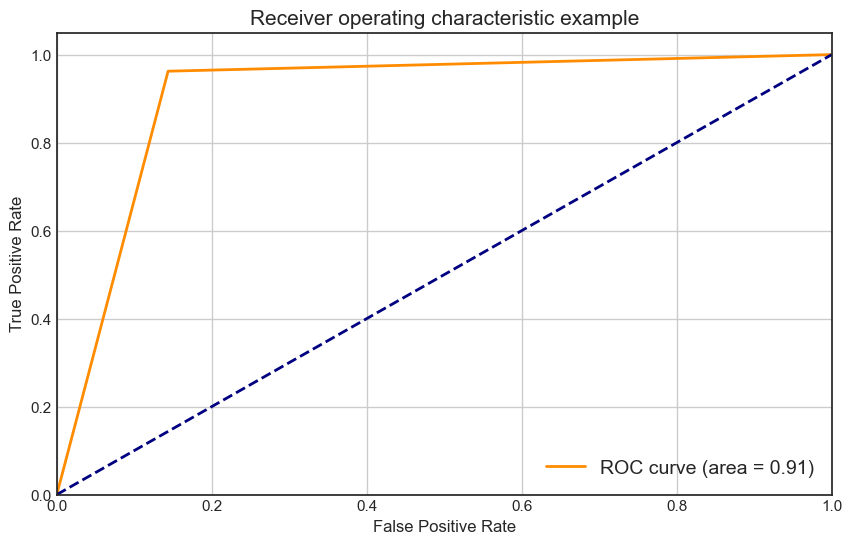

In [115]:
plot_roc(y_true_2, y_score_2)

In [38]:
def positive_negative_measurement(y_true, y_score):
    # Initialization
    TRUE_POSITIVE = 0
    FALSE_POSITIVE = 0
    TRUE_NEGATIVE = 0
    FALSE_NEGATIVE = 0
    
    # Calculating the model
    for i in range(len(y_score)):
        if y_true[i] == y_score[i] == 1:
            TRUE_POSITIVE += 1
        if (y_score[i] == 1) and (y_true[i] != y_score[i]):
            FALSE_POSITIVE += 1
        if y_true[i] == y_score[i] == 0:
            TRUE_NEGATIVE += 1
        if (y_score[i] == 0) and (y_true[i] != y_score[i]):
            FALSE_NEGATIVE += 1

    return(TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE)

In [39]:
TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE = positive_negative_measurement(y_true_2, y_score_2)
postives_negatives = [[TRUE_POSITIVE, FALSE_POSITIVE], 
                      [FALSE_NEGATIVE, TRUE_NEGATIVE]]

<Axes: >

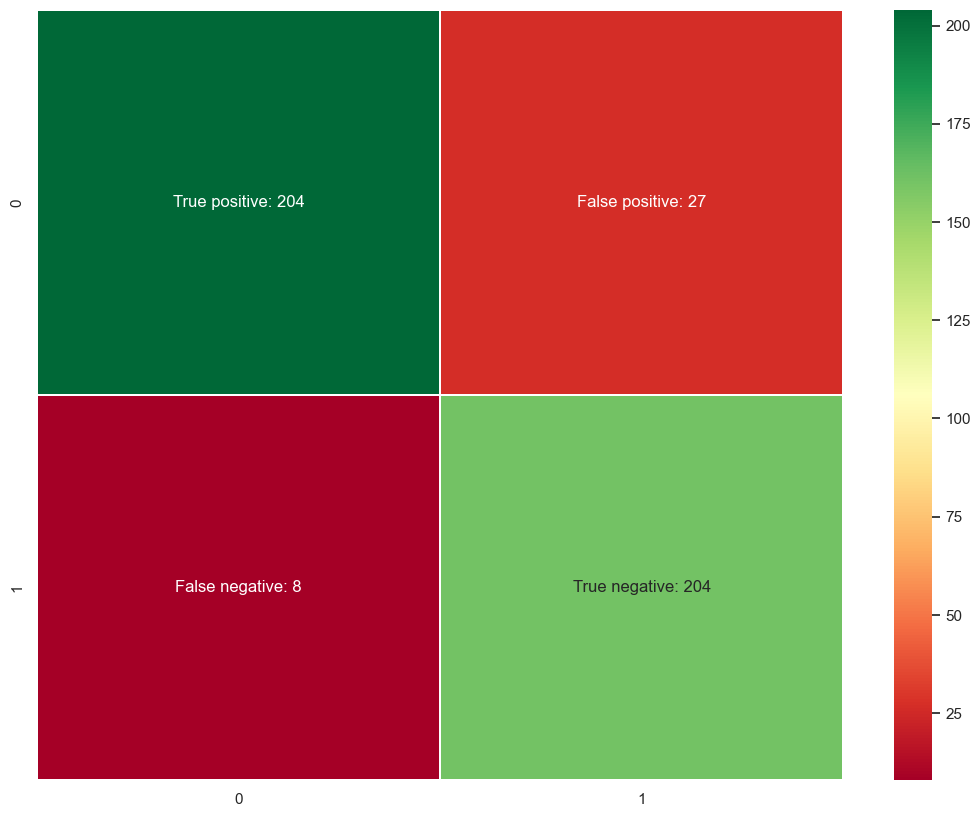

In [40]:
import seaborn as sns
sns.set()
labels =  np.array([['True positive: ' + str(TRUE_POSITIVE),
                     'False positive: ' + str(FALSE_POSITIVE)],
                    ['False negative: ' + str(FALSE_NEGATIVE),
                     'True negative: ' + str(TRUE_POSITIVE)]])
plt.figure(figsize = (13, 10))
sns.heatmap(postives_negatives, annot = labels, linewidths = 0.1, fmt="", cmap = 'RdYlGn')

In [41]:
# Sensitivity | Recall | hit rate | true positive rate (TPR)
sensitivity = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_NEGATIVE)
print("Sensitivity: ", sensitivity)

Sensitivity:  0.9622641509433962


In [42]:
# Specificity | selectivity | true negative rate (TNR)
specifity = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Specifity: ", specifity)

Specifity:  0.9526627218934911


In [43]:
# Precision | positive predictive value (PPV)
predcision = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_POSITIVE)
print("Precision: ", predcision)

Precision:  0.8831168831168831


In [44]:
# Negative predictive value (NPV)
npv = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Negative predictive value: ", npv)

Negative predictive value:  0.9526627218934911


In [45]:
# Accuracy 
accuracy = (TRUE_POSITIVE + TRUE_NEGATIVE) / (TRUE_POSITIVE + FALSE_POSITIVE + TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Accuracy: ", accuracy)

Accuracy:  0.9125


### 4.2. Evaluating Inception

In [46]:
# Compute test set predictions
NUMBER_TEST_SAMPLES = 400

y_true = valid_targets[:NUMBER_TEST_SAMPLES]
y_score = []
for index in range(NUMBER_TEST_SAMPLES): #compute one at a time due to memory constraints
    probs = predict(img_path = valid_files[index])
    print("Real values {}...".format(index+1) + "Melanoma : ", valid_targets[index][0], " | Other : ", valid_targets[index][1])
    print("---------------------------------------------------------------------------")
    y_score.append(probs)
    
correct = np.array(y_true) == np.array(y_score)

1/1 [==============================] - 0s 99ms/step
Prediction... Melanoma :  0.19571172  | Other :  0.8042883
Real values 1...Melanoma :  0.0  | Other :  1.0
---------------------------------------------------------------------------
1/1 [==============================] - 0s 98ms/step
Prediction... Melanoma :  0.04852244  | Other :  0.9514776
Real values 2...Melanoma :  0.0  | Other :  1.0
---------------------------------------------------------------------------
1/1 [==============================] - 0s 98ms/step
Prediction... Melanoma :  0.9999912  | Other :  8.835066e-06
Real values 3...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------
1/1 [==============================] - 0s 88ms/step
Prediction... Melanoma :  0.99998367  | Other :  1.6312177e-05
Real values 4...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------
1/1 [==============================] - 0s 95ms/step
Pr

In [47]:
print("Accuracy = %2.2f%%" % (np.mean(correct)*100))

Accuracy = 91.25%


In [48]:
# Re-ordering the actual y (for ROC)
y_true_2 = []
for i in range(len(y_true)):
    y_true_2.append(y_true[i][0])
    
# Re-ordering the predicte y (for ROC)
y_score_2 = []
for i in range(len(y_score)):
    y_score_2.append(y_score[i][0])

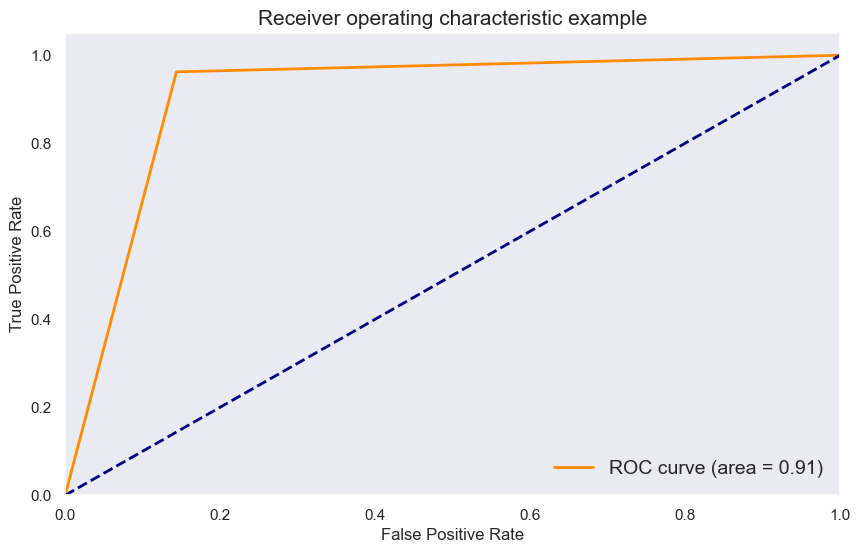

In [49]:
plot_roc(y_true_2, y_score_2)

In [50]:
def positive_negative_measurement(y_true, y_score):
    # Initialization
    TRUE_POSITIVE = 0
    FALSE_POSITIVE = 0
    TRUE_NEGATIVE = 0
    FALSE_NEGATIVE = 0
    
    # Calculating the model
    for i in range(len(y_score)):
        if y_true[i] == y_score[i] == 1:
            TRUE_POSITIVE += 1
        if (y_score[i] == 1) and (y_true[i] != y_score[i]):
            FALSE_POSITIVE += 1
        if y_true[i] == y_score[i] == 0:
            TRUE_NEGATIVE += 1
        if (y_score[i] == 0) and (y_true[i] != y_score[i]):
            FALSE_NEGATIVE += 1

    return(TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE)

In [51]:
TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE = positive_negative_measurement(y_true_2, y_score_2)
postives_negatives = [[TRUE_POSITIVE, FALSE_POSITIVE], 
                      [FALSE_NEGATIVE, TRUE_NEGATIVE]]

<Axes: >

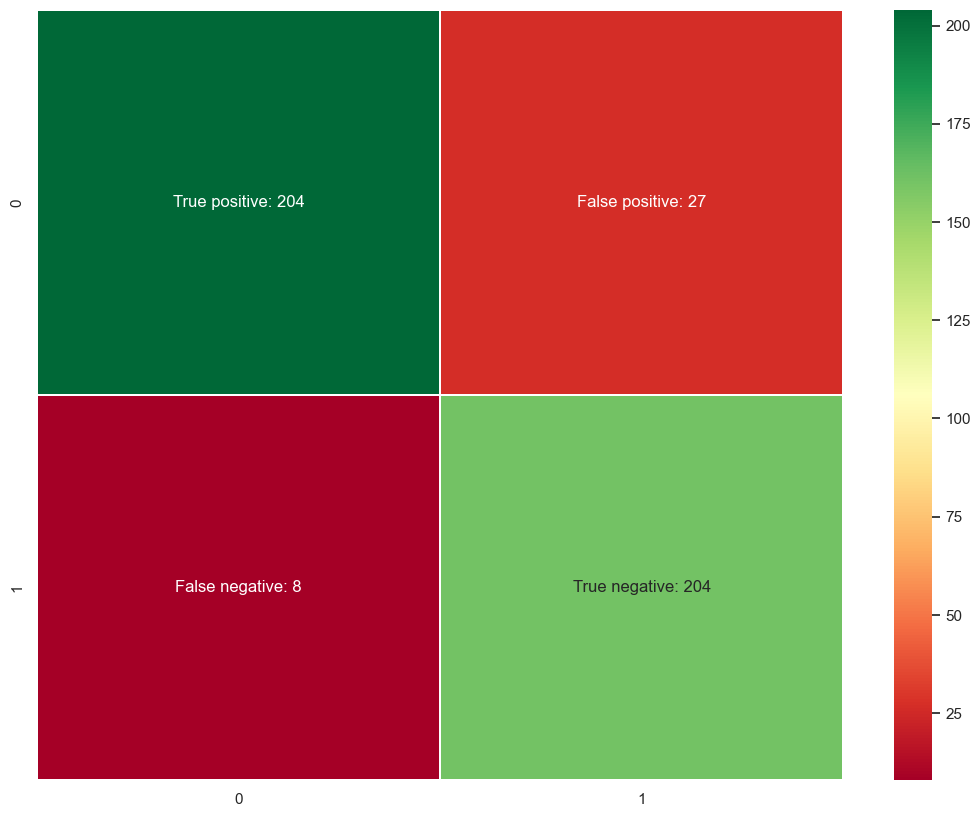

In [52]:
import seaborn as sns
sns.set()
labels =  np.array([['True positive: ' + str(TRUE_POSITIVE),
                     'False positive: ' + str(FALSE_POSITIVE)],
                    ['False negative: ' + str(FALSE_NEGATIVE),
                     'True negative: ' + str(TRUE_POSITIVE)]])
plt.figure(figsize = (13, 10))
sns.heatmap(postives_negatives, annot = labels, linewidths = 0.1, fmt="", cmap = 'RdYlGn')

In [53]:
# Sensitivity | Recall | hit rate | true positive rate (TPR)
sensitivity = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_NEGATIVE)
print("Sensitivity: ", sensitivity)

# Specificity | selectivity | true negative rate (TNR)
specifity = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Specifity: ", specifity)

# Precision | positive predictive value (PPV)
# predcision = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_POSITIVE)
# print("Precision: ", predcision)

# Negative predictive value (NPV)
npv = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Negative predictive value: ", npv)

# Accuracy 
accuracy = (TRUE_POSITIVE + TRUE_NEGATIVE) / (TRUE_POSITIVE + FALSE_POSITIVE + TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Accuracy: ", accuracy)

Sensitivity:  0.9622641509433962
Specifity:  0.9526627218934911
Negative predictive value:  0.9526627218934911
Accuracy:  0.9125


## 5. Ensembling the models

In [54]:
from keras.layers import Input

In [55]:
# Single input for multiple models
model_input = Input(shape=(512, 512, 3))

In [56]:
def mobilenet_architecture():
    """
    Pre-build architecture of mobilenet for our dataset.
    """
    # Imprting the model
    from keras.applications.mobilenet import MobileNet

    # Pre-build model
    base_model = MobileNet(include_top = False, weights = None, input_tensor = model_input)

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    mobilenet_model = Model(base_model.input, output)
    
    # Getting the summary of architecture
    #mobilenet_model.summary()
    
    # Compiling the model
    mobilenet_model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
                            loss = 'categorical_crossentropy', 
                            metrics = ['accuracy'])

    return mobilenet_model

In [57]:
# Model 1
mobilenet_model = mobilenet_architecture()
mobilenet_model.load_weights("./Saved models/weights.best.mobilenet.hdf5")

c:\Users\bmpra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\optimizers\legacy\adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [58]:
def inception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model 
    from keras.applications.inception_v3 import InceptionV3

    # Pre-build model
    base_model = InceptionV3(include_top = False, weights = None, input_tensor = model_input)

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    inception_model = Model(base_model.input, output)
    
    # Summary of the model
    #inception_model.summary()
    
    # Compiling the model
    inception_model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
                            loss = 'categorical_crossentropy', 
                            metrics = ['accuracy'])
    
    return inception_model

In [59]:
# Model 2
inception_model = inception_architecture()
inception_model.load_weights("./Saved models/weights.best.inception.hdf5")

In [60]:
def xception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model
    from keras.applications.xception import Xception

    # Pre-build model
    base_model = Xception(include_top = False, weights = None, input_tensor = model_input)

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    xception_model = Model(base_model.input, output)

    # Summary of the model
    #xception_model.summary()
    
    # Compiling the model
    xception_model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
                           loss = 'categorical_crossentropy', 
                           metrics = ['accuracy'])

    return xception_model

In [61]:
# Model 3
xception_model = xception_architecture()
xception_model.load_weights("./Saved models/weights.best.xception.hdf5")

In [62]:
# Appending all models
models = [mobilenet_model, inception_model, xception_model]

In [63]:
def ensemble(models, model_input):
    
    outputs = [model.outputs[0] for model in models]
    
    y = keras.layers.Average()(outputs)
    
    model = Model(model_input, y, name='ensemble')
    
    return model

In [64]:
# Getting ensemble model
ensemble_model = ensemble(models, model_input)

In [65]:
image_to_predict = path_to_tensor("ISIC_0032258.jpg").astype('float32')/255.
ensemble_model.predict(image_to_predict)

1/1 [==============================] - 3s 3s/step


array([[0.43887115, 0.56112885]], dtype=float32)

## 5. 2. Evaluating ensemble model

In [66]:
# Compute test set predictions
NUMBER_TEST_SAMPLES = 400

y_true = valid_targets[:NUMBER_TEST_SAMPLES]
y_score = []
for index in range(NUMBER_TEST_SAMPLES): #compute one at a time due to memory constraints
    image_to_predict = path_to_tensor(valid_files[index]).astype("float32")/255.
    probs = ensemble_model.predict(image_to_predict)
    if np.argmax(probs) == 0:
        y_score.append([1., 0.])
    elif np.argmax(probs) == 1:
        y_score.append([0., 1.])
    print("Predicted value {}... ".format(index+1) + " Melanoma : ", probs[0][0],  " | Other : ", probs[0][1])
    print("Real values {}...".format(index+1) + "      Melanoma : ", valid_targets[index][0], "      | Other : ", valid_targets[index][1])
    print("---------------------------------------------------------------------------")
    
    
correct = np.array(y_true) == np.array(y_score)

1/1 [==============================] - 0s 468ms/step
Predicted value 1...  Melanoma :  0.40264535  | Other :  0.5973547
Real values 1...      Melanoma :  0.0       | Other :  1.0
---------------------------------------------------------------------------
1/1 [==============================] - 0s 485ms/step
Predicted value 2...  Melanoma :  0.05287416  | Other :  0.94712585
Real values 2...      Melanoma :  0.0       | Other :  1.0
---------------------------------------------------------------------------
1/1 [==============================] - 0s 493ms/step
Predicted value 3...  Melanoma :  0.97738093  | Other :  0.022619136
Real values 3...      Melanoma :  1.0       | Other :  0.0
---------------------------------------------------------------------------
1/1 [==============================] - 0s 494ms/step
Predicted value 4...  Melanoma :  0.99913615  | Other :  0.00086384534
Real values 4...      Melanoma :  1.0       | Other :  0.0
-------------------------------------------------

KeyboardInterrupt: 

In [67]:
print("Accuracy = %2.2f%%" % (np.mean(correct)*100))

Accuracy = 91.25%


In [68]:
# Re-ordering the actual y (for ROC)
y_true_2 = []
for i in range(len(y_true)):
    y_true_2.append(y_true[i][0])
    
# Re-ordering the predicte y (for ROC)
y_score_2 = []
for i in range(len(y_score)):
    y_score_2.append(y_score[i][0])

In [69]:
plot_roc(y_true_2, y_score_2)

ValueError: Found input variables with inconsistent numbers of samples: [400, 32]

In [70]:
def positive_negative_measurement(y_true, y_score):
    # Initialization
    TRUE_POSITIVE = 0
    FALSE_POSITIVE = 0
    TRUE_NEGATIVE = 0
    FALSE_NEGATIVE = 0
    
    # Calculating the model
    for i in range(len(y_score)):
        if y_true[i] == y_score[i] == 1:
            TRUE_POSITIVE += 1
        if (y_score[i] == 1) and (y_true[i] != y_score[i]):
            FALSE_POSITIVE += 1
        if y_true[i] == y_score[i] == 0:
            TRUE_NEGATIVE += 1
        if (y_score[i] == 0) and (y_true[i] != y_score[i]):
            FALSE_NEGATIVE += 1

    return(TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE)

In [71]:
TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE = positive_negative_measurement(y_true_2, y_score_2)
postives_negatives = [[TRUE_POSITIVE, FALSE_POSITIVE], 
                      [FALSE_NEGATIVE, TRUE_NEGATIVE]]

<Axes: >

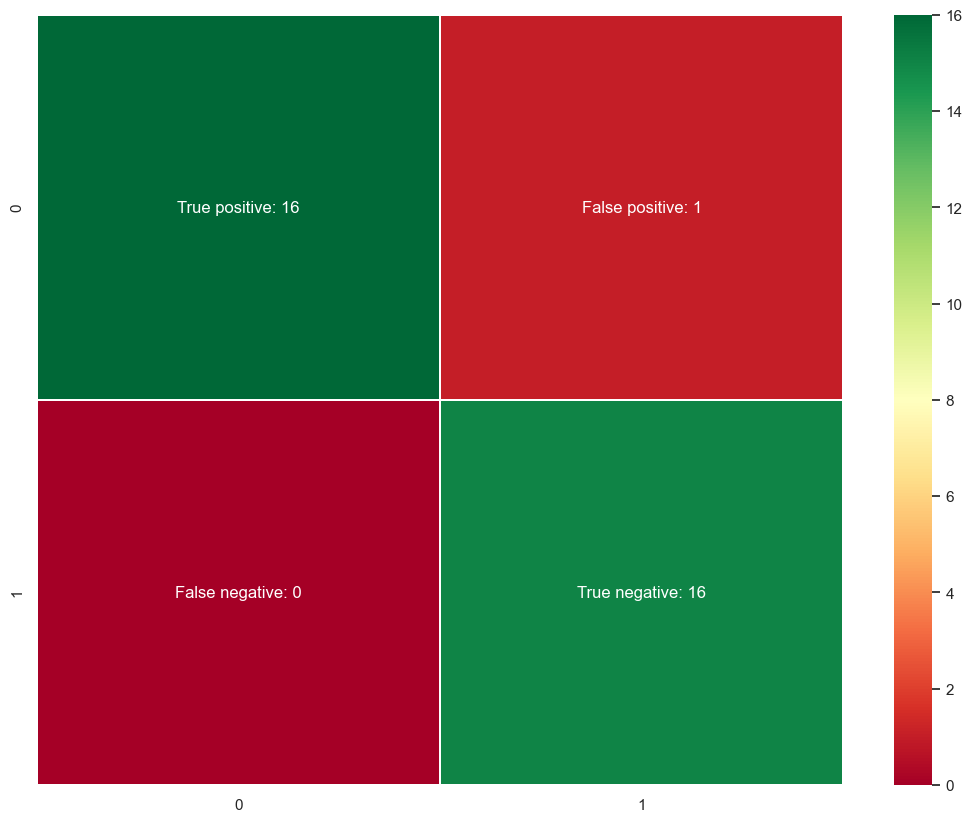

In [72]:
import seaborn as sns
sns.set()
labels =  np.array([['True positive: ' + str(TRUE_POSITIVE),
                     'False positive: ' + str(FALSE_POSITIVE)],
                    ['False negative: ' + str(FALSE_NEGATIVE),
                     'True negative: ' + str(TRUE_POSITIVE)]])
plt.figure(figsize = (13, 10))
sns.heatmap(postives_negatives, annot = labels, linewidths = 0.1, fmt="", cmap = 'RdYlGn')

In [73]:
# Sensitivity | Recall | hit rate | true positive rate (TPR)
sensitivity = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_NEGATIVE)
print("Sensitivity: ", sensitivity)

# Specificity | selectivity | true negative rate (TNR)
specifity = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Specifity: ", specifity)

# Precision | positive predictive value (PPV)
# predcision = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_POSITIVE)
# print("Precision: ", predcision)

# Negative predictive value (NPV)
npv = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Negative predictive value: ", npv)

# Accuracy 
accuracy = (TRUE_POSITIVE + TRUE_NEGATIVE) / (TRUE_POSITIVE + FALSE_POSITIVE + TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Accuracy: ", accuracy)

Sensitivity:  1.0
Specifity:  1.0
Negative predictive value:  1.0
Accuracy:  0.96875


## 6. Localization

In [74]:
# Importing the libraries
from keras.applications.mobilenet import preprocess_input
import scipy
import cv2

In [75]:
path_to_model_weight = "./Saved models/weights.best.mobilenet.hdf5"

In [88]:
img_path = valid_files[3]
img_path

'./Dataset/melanoma\\ISIC_0025611_90_angle_flipped.jpg'

In [77]:
def getting_two_layer_weights(path_model_weight = path_to_model_weight):
    # The model

    # Imprting the model
    from keras.applications.mobilenet import MobileNet

    # Pre-build model
    base_model = MobileNet(include_top = False, weights = None, input_shape = (512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    model = Model(base_model.input, output)
    #model.summary()

    # Compiling the model
    model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
                  loss = 'categorical_crossentropy', 
                  metrics = ['accuracy'])
    
    # loading the weights
    model.load_weights(path_model_weight)
    
    # Getting the AMP layer weight
    all_amp_layer_weights = model.layers[-1].get_weights()[0]
    
    # Extracting the wanted output
    mobilenet_model = Model(inputs = model.input, outputs = (model.layers[-3].output, model.layers[-1].output))
    
    return mobilenet_model, all_amp_layer_weights

In [78]:
mobilenet_model, all_amp_layer_weights = getting_two_layer_weights(path_to_model_weight)

c:\Users\bmpra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\optimizers\legacy\adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [79]:
def mobilenet_CAM(img_path, model, all_amp_layer_weights):
    # Getting filtered images from last convolutional layer + model prediction output
    last_conv_output, predictions = model.predict(path_to_tensor(img_path)) # last_conv_output.shape = (1, 16, 16, 1024)
    
    # Converting the dimension of last convolutional layer to 16 x 16 x 1024     
    last_conv_output = np.squeeze(last_conv_output)
    
    # Model's prediction
    predicted_class = np.argmax(predictions)
    
    # Bilinear upsampling (resize each image to size of original image)
    mat_for_mult = scipy.ndimage.zoom(last_conv_output, (32, 32, 1), order = 1)  # dim from (16, 16, 1024) to (512, 512, 1024)
    
    # Getting the AMP layer weights
    amp_layer_weights = all_amp_layer_weights[:, predicted_class] # dim: (1024,)    
    
    # CAM for object class that is predicted to be in the image
    final_output = np.dot(mat_for_mult, amp_layer_weights) # dim: 512 x 512

    # Return class activation map (CAM)
    return final_output, predicted_class

In [80]:
final_output, predicted_class = mobilenet_CAM(img_path, mobilenet_model, all_amp_layer_weights)

1/1 [==============================] - 1s 662ms/step


In [89]:
def plot_CAM(img_path, ax, model, all_amp_layer_weights):
    # Loading the image / resizing to 512x512 / Converting BGR to RGB
    #im = cv2.resize(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB), (512, 512))
    im = path_to_tensor(img_path).astype("float32")/255.
    
    # Plotting the image
    ax.imshow(im.squeeze(), vmin=0, vmax=255)
    
    # Getting the class activation map
    CAM, pred = mobilenet_CAM(img_path, model, all_amp_layer_weights)
    
    CAM = (CAM - CAM.min()) / (CAM.max() - CAM.min())
    
    # Plotting the class activation map
    ax.imshow(CAM, cmap = "jet", alpha = 0.5, interpolation='nearest', vmin=0, vmax=1)

1/1 [==============================] - 0s 126ms/step


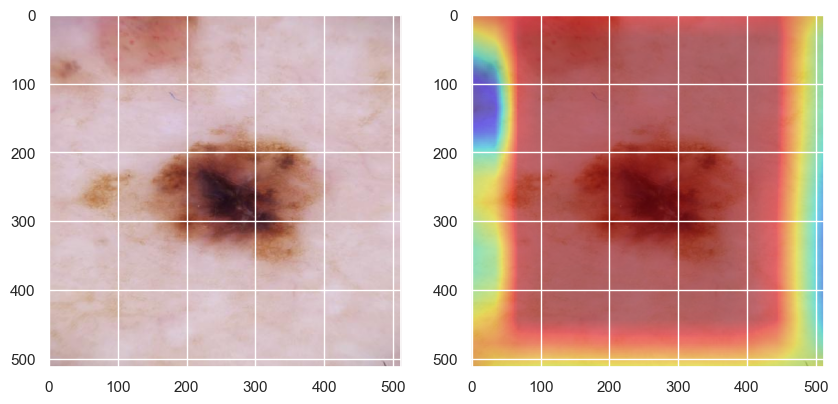

In [90]:
# Visualizing images with and without localization
# Canvas
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (10, 10))
# Image without localization
ax[0].imshow((path_to_tensor(img_path).astype('float32')/255).squeeze())
# Image with localization
CAM = plot_CAM(img_path, ax[1], mobilenet_model, all_amp_layer_weights)
plt.show()

1/1 [==============================] - 0s 96ms/step


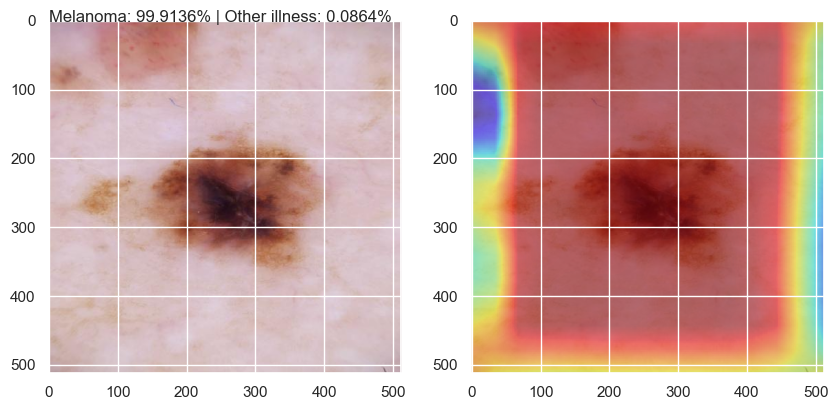

In [91]:
# Getting the iamge tensor
# image_to_predict = path_to_tensor(img_path).astype('float32')/255
image_to_predict = path_to_tensor(valid_files[3]).astype("float32")/255.

# Predicting the image
prediction = ensemble_model.predict(image_to_predict)
prediction_final = "Melanoma: " + str(np.round(prediction[0][0]*100, decimals = 4)) + "%" + \
                   " | Other illness: " + str(np.round(prediction[0][1]*100, decimals = 4)) + "%"

# Canvas initialization
fig = plt.figure(figsize = (10, 10))

# First image
ax = fig.add_subplot(121)
ax.imshow(image_to_predict.squeeze())
ax.text(0.3, 1.6, prediction_final)

# Second image
ax = fig.add_subplot(122)
CAM = plot_CAM(img_path, ax, mobilenet_model, all_amp_layer_weights)

plt.show()